# Repetition Lag-CRP

> Separate temporal contiguity curves by presentation index for repeated items.

The repetition Lag-CRP extends the standard Lag-CRP analysis to study lists containing repeated items. For each recall of a repeated item, the analysis separately tabulates lag transitions relative to each of the item's study positions. This produces one CRP curve per presentation index, revealing whether transitions from repeated items cluster around the first or second occurrence.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.repcrp import (
    plot_rep_crp,
    subject_rep_crp,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

In [2]:
data_path = "../datasets/prepared/BroitmanKahana2024.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .45]
trial_query = "data['listLength'] > 0"
min_lag = 4
max_lag = 5
size = 2
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


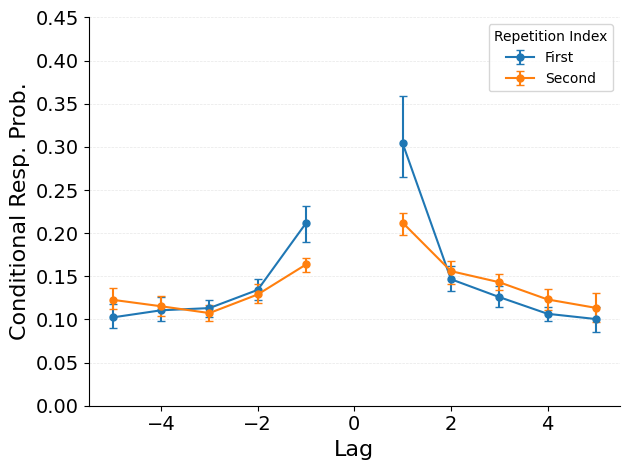

In [4]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The plot shows separate CRP curves for transitions relative to the first and second presentation of repeated items. Key patterns:

- **First vs. second presentation bias**: if one presentation's curve is consistently higher, participants preferentially transition relative to that occurrence.
- **Lag-specific contiguity**: peaks around nearby lags indicate whether repeated-item transitions preserve temporal neighborhood structure.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a list, or `None` for automatic scaling.
- `trial_query` — query selecting trials.
- `min_lag` — minimum absolute lag included in the analysis.
- `max_lag` — maximum absolute lag displayed.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.